# Домашнее задание 6. Автоматизация расчетов с помощью Apache AirFlow

In [ ]:
from datetime import datetime, timedelta
import logging
import pandas as pd
from pathlib import Path
from airflow import DAG
from airflow.operators.python import PythonOperator
from airflow.providers.postgres.hooks.postgres import PostgresHook
from airflow.models import Variable
from airflow.exceptions import AirflowException
from sqlalchemy import create_engine

logger = logging.getLogger(__name__)

DAGS_DIR = Path(__file__).parent
BASE_DIR = DAGS_DIR.parent
DATA_DIR = BASE_DIR / 'data_files'
OUTPUT_DIR = BASE_DIR / 'result_files'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TABLES = ['customer', 'product', 'orders', 'order_items']

TABLE_CREATION_SQL = {
    'customer': """
        CREATE TABLE IF NOT EXISTS customer (
            customer_id BIGINT NOT NULL,
            first_name VARCHAR NOT NULL,
            last_name VARCHAR,
            gender VARCHAR NOT NULL,
            DOB VARCHAR,
            job_title VARCHAR,
            job_industry_category VARCHAR,
            wealth_segment VARCHAR,
            deceased_indicator VARCHAR NOT NULL,
            owns_car VARCHAR NOT NULL,
            address TEXT NOT NULL,
            postcode INTEGER NOT NULL,
            state VARCHAR,
            country VARCHAR,
            property_valuation INTEGER NOT NULL
        );
    """,
    'product': """
        CREATE TABLE IF NOT EXISTS product (
            product_id BIGINT,
            brand VARCHAR,
            product_line VARCHAR,
            product_class VARCHAR,
            product_size VARCHAR,
            list_price FLOAT NOT NULL,
            standard_cost FLOAT
        );
    """,
    'orders': """
        CREATE TABLE IF NOT EXISTS orders (
            order_id BIGINT PRIMARY KEY,
            customer_id BIGINT NOT NULL,
            order_date DATE,
            online_order BOOLEAN,
            order_status VARCHAR NOT NULL
        );
    """,
    'order_items': """
        CREATE TABLE IF NOT EXISTS order_items (
            order_item_id BIGINT PRIMARY KEY,
            order_id BIGINT NOT NULL,
            product_id BIGINT NOT NULL,
            quantity INTEGER NOT NULL,
            item_list_price_at_sale FLOAT NOT NULL,
            item_standard_cost_at_sale FLOAT
        );
    """
}


def get_postgres_connection():
    """
    Создает подключение к PostgreSQL через psycopg2
    """
    try:
        hook = PostgresHook(postgres_conn_id='postgres_default')
        conn = hook.get_conn()
        return conn
    except Exception as e:
        logger.error(f"Ошибка подключения к PostgreSQL: {str(e)}")
        raise


def check_database_connection():
    """Проверка подключения к базе данных"""
    try:
        logger.info("Проверка подключения к БД")

        conn = get_postgres_connection()
        cursor = conn.cursor()
        cursor.execute("SELECT current_database();")
        db_name = cursor.fetchone()

        logger.info(f"Подключение успешно! База данных: {db_name[0]}")

        cursor.close()
        conn.close()
        return True

    except Exception as e:
        logger.error(f"Ошибка подключения к БД: {str(e)}")
        raise AirflowException(f"Database connection failed: {str(e)}")


def check_and_create_tables():
    """
    Проверяет существование всех таблиц и создает отсутствующие
    """
    try:
        logger.info("Старт проверки существования таблиц")

        conn = get_postgres_connection()
        cursor = conn.cursor()

        tables_to_create = []
        for table_name in TABLES:
            cursor.execute("""
                SELECT EXISTS (
                    SELECT FROM information_schema.tables 
                    WHERE table_schema = 'public' 
                    AND table_name = %s
                );
            """, (table_name,))

            table_exists = cursor.fetchone()[0]

            if not table_exists:
                logger.info(f"Таблица '{table_name}' не существует")
                tables_to_create.append(table_name)
            else:
                logger.info(f"Таблица '{table_name}' существует")

        if not tables_to_create:
            logger.info("Все таблицы существуют, создание не требуется")
            cursor.close()
            conn.close()
            return True

        logger.info(f"Создание отсутствующих таблиц: {', '.join(tables_to_create)}")

        for table_name in tables_to_create:
            logger.info(f"Создание таблицы '{table_name}'...")
            cursor.execute(TABLE_CREATION_SQL[table_name])
            logger.info(f"Таблица '{table_name}' успешно создана")

        conn.commit()
        cursor.close()
        conn.close()

        logger.info("Все необходимые таблицы успешно созданы")
        return True

    except Exception as e:
        logger.error(f"Ошибка при проверке/создании таблиц: {str(e)}")
        raise AirflowException(f"Failed to check/create tables: {str(e)}")


def load_table_data(table_name, delimiter=','):
    """
    Универсальная функция для загрузки данных в таблицу из CSV файла
    """
    try:
        csv_file = DATA_DIR / f"{table_name}.csv"

        if not csv_file.exists():
            logger.error(f"Файл не найден: {csv_file}")
            raise AirflowException(f"File not found: {csv_file}")

        logger.info(f"Старт загрузки данных в таблицу '{table_name}'...")

        df = pd.read_csv(csv_file, delimiter=delimiter, encoding="utf-8")
        logger.info(f"Прочитано {len(df)} строк из файла {table_name}.csv")

        if len(df) == 0:
            logger.warning(f"Файл {table_name}.csv пустой!")
            return True

        conn = get_postgres_connection()
        cursor = conn.cursor()

        cursor.execute("""
            SELECT EXISTS (
                SELECT FROM information_schema.tables 
                WHERE table_schema = 'public' 
                AND table_name = %s
            );
        """, (table_name,))

        if not cursor.fetchone()[0]:
            logger.error(f"Таблица '{table_name}' не существует")
            cursor.close()
            conn.close()
            raise AirflowException(f"Table '{table_name}' does not exist")

        cursor.execute(f"""
            SELECT column_name 
            FROM information_schema.columns 
            WHERE table_schema = 'public' 
            AND table_name = %s 
            ORDER BY ordinal_position;
        """, (table_name,))

        table_columns = [row[0] for row in cursor.fetchall()]
        columns_str = ', '.join(table_columns)
        placeholders = ', '.join(['%s'] * len(table_columns))
        insert_sql = f"INSERT INTO {table_name} ({columns_str}) VALUES ({placeholders})"

        df = df.where(pd.notnull(df), None)

        data_files = []
        for _, row in df.iterrows():
            values = []
            for col in table_columns:
                if col in df.columns:
                    values.append(row[col])
                else:
                    values.append(None)
            data_files.append(tuple(values))

        batch_size = 1000
        total_inserted = 0

        for i in range(0, len(data_files), batch_size):
            batch = data_files[i:i + batch_size]
            cursor.executemany(insert_sql, batch)
            total_inserted += len(batch)

            if i % (batch_size * 10) == 0:
                logger.info(f"  Загружено {total_inserted} строк...")

        conn.commit()
        cursor.close()
        conn.close()

        logger.info(f"Успешно загружено {total_inserted} строк в таблицу '{table_name}'")
        return True

    except pd.errors.EmptyDataError:
        logger.error(f"CSV файл пустой")
        return True
    except Exception as e:
        logger.error(f"Ошибка при загрузке данных в таблицу '{table_name}': {str(e)}")
        raise AirflowException(f"Failed to load {table_name} data")


def execute_top_customers_query():
    """
    Выполняет SQL запрос для получения топ-3 клиентов по сумме заказов.
    Сохраняет результат в файл
    """
    try:
        current_date = datetime.now().strftime("%Y-%m-%d")
        output_file = OUTPUT_DIR / f"{current_date}_top_3_customers.txt"

        logger.info(f"Старт выполнения запроса для получения топ-3 клиентов")
        logger.info(f"Файл для сохранения: {output_file}")

        sql_query = """
        WITH order_rate AS (
            SELECT c.first_name, c.last_name, SUM(COALESCE(orders_sum.order_sum, 0)) AS total_sum
            FROM customer c 
            LEFT JOIN (
                SELECT o.customer_id, o.order_id, SUM(quantity * item_list_price_at_sale) order_sum
                FROM order_items oi 
                LEFT JOIN orders o ON oi.order_id = o.order_id 
                GROUP BY o.order_id
            ) AS orders_sum ON c.customer_id = orders_sum.customer_id
            GROUP BY c.customer_id, c.first_name, c.last_name
        )
        (SELECT * 
        FROM order_rate 
        ORDER BY total_sum DESC 
        LIMIT 3) 
        UNION ALL
        (SELECT * 
        FROM order_rate 
        ORDER BY total_sum
        LIMIT 3)
        """

        conn = get_postgres_connection()
        cursor = conn.cursor()
        cursor.execute(sql_query)
        results = cursor.fetchall()
        cursor.close()
        conn.close()

        if not results:
            logger.error("Ошибка: запрос вернул 0 строк")
            with open(output_file, 'w', encoding='utf-8') as f:
                f.write("Запрос вернул 0 строк.\n")
            return False

        logger.info(f"Получено {len(results)} строк результатов")

        with open(output_file, 'w', encoding='utf-8') as f:
            f.write("first_name\tlast_name\ttotal_sum\n")

            for row in results:
                line = f"{row[0]}\t{row[1]}\t{row[2]}\n"
                f.write(line)

        logger.info(f"Результаты успешно сохранены в файл: {output_file}")
        return True

    except Exception as e:
        logger.error(f"Ошибка при выполнении запроса top-3: {str(e)}")

        try:
            current_date = datetime.now().strftime("%Y-%m-%d")
            output_file = OUTPUT_DIR / f"{current_date}_top_3_customers.txt"
            with open(output_file, 'w', encoding='utf-8') as f:
                f.write(f"Ошибка при выполнении запроса: {str(e)}\n")
        except:
            pass

        raise AirflowException(f"Failed to execute top customers query: {str(e)}")


def execute_top_by_wealth_segment_query():
    """
    Выполняет SQL запрос для получения топ-5 заказов по каждому wealth_segment.
    Сохраняет результат в файл
    """
    try:
        current_date = datetime.now().strftime("%Y-%m-%d")
        output_file = OUTPUT_DIR / f"{current_date}_top_5_by_wealth_segment.txt"

        logger.info(f"Старт выполнения запроса для получения топ-5 клиентов по wealth_segment")
        logger.info(f"Файл для сохранения: {output_file}")

        sql_query = """
        SELECT wealth_segment, order_id, first_name, last_name, order_sum
        FROM (
            SELECT wealth_segment, o.order_id, first_name, last_name
            , SUM(quantity * item_list_price_at_sale) AS order_sum
            , RANK() OVER (PARTITION BY wealth_segment ORDER BY SUM(quantity * item_list_price_at_sale) DESC, 
                o.order_id) AS sum_rank
            FROM order_items oi 
            LEFT JOIN orders o ON oi.order_id = o.order_id 
            LEFT JOIN customer c ON o.customer_id = c.customer_id 
            GROUP BY wealth_segment, o.order_id, first_name, last_name 
        ) AS grouped_by_wealth_segment
        WHERE sum_rank < 6
        ORDER BY wealth_segment, sum_rank
        """

        conn = get_postgres_connection()
        cursor = conn.cursor()
        cursor.execute(sql_query)
        results = cursor.fetchall()
        cursor.close()
        conn.close()

        if not results:
            logger.error("Ошибка: запрос вернул 0 строк")
            with open(output_file, 'w', encoding='utf-8') as f:
                f.write("Ошибка: запрос вернул 0 строк.\n")
            return False

        logger.info(f"Получено {len(results)} строк результатов")

        segments = {}
        for row in results:
            segment = row[0]
            if segment not in segments:
                segments[segment] = []
            segments[segment].append(row)

        with open(output_file, 'w', encoding='utf-8') as f:
            f.write("wealth_segment\torder_id\tfirst_name\tlast_name\torder_sum\n")

            for row in results:
                line = f"{row[0]}\t{row[1]}\t{row[2]}\t{row[3]}\t{row[4]}\n"
                f.write(line)

        logger.info(f"Результаты успешно сохранены в файл: {output_file}")
        return True

    except Exception as e:
        logger.error(f"Ошибка при выполнении запроса top-5: {str(e)}")

        try:
            current_date = datetime.now().strftime("%Y-%m-%d")
            output_file = OUTPUT_DIR / f"{current_date}_top_5_by_wealth_segment.txt"
            with open(output_file, 'w', encoding='utf-8') as f:
                f.write(f"Ошибка при выполнении запроса: {str(e)}\n")
        except:
            pass

        raise AirflowException(f"Failed to execute top-5 by wealth segment query: {str(e)}")


def log_completion():
    """Логирование успешного завершения всех задач"""
    logger.info("Все задачи успешно выполнены")

    current_date = datetime.now().strftime("%Y-%m-%d")
    top_customers_file = OUTPUT_DIR / f"{current_date}_top_3_customers.txt"
    top_wealth_file = OUTPUT_DIR / f"{current_date}_top_5_by_wealth_segment.txt"

    if top_customers_file.exists():
        file_size = top_customers_file.stat().st_size
        logger.info(f"Файл с топ-3 клиентами создан: {top_customers_file} ({file_size} байт)")
    else:
        logger.warning(f"Файл с топ-3 клиентами не создан: {top_customers_file}")

    if top_wealth_file.exists():
        file_size = top_wealth_file.stat().st_size
        logger.info(f"Файл с топ-5 по wealth segment создан: {top_wealth_file} ({file_size} байт)")
    else:
        logger.warning(f"Файл с топ-5 по wealth segment не создан: {top_wealth_file}")
    return True


def check_output_directory():
    """Проверка и создание директории для результатов"""
    try:
        if not OUTPUT_DIR.exists():
            OUTPUT_DIR.mkdir(parents=True)
            logger.info(f"Создана директория для результатов: {OUTPUT_DIR}")
        else:
            logger.info(f"Директория для результатов уже существует: {OUTPUT_DIR}")

        test_file = OUTPUT_DIR / "test_write.txt"
        test_file.write_text("test")
        test_file.unlink()

        logger.info("Директория для результатов доступна для записи")
        return True

    except Exception as e:
        logger.error(f"Ошибка при работе с директорией для результатов: {str(e)}")
        raise AirflowException(f"Output directory error: {str(e)}")


default_args = {
    'owner': 'airflow',
    'depends_on_past': False,
    'start_date': datetime(2025, 12, 20),
    'retries': 1,
    'retry_delay': timedelta(minutes=1),
}

with DAG(
        dag_id='homework_6_tasks',
        default_args=default_args,
        description='Проверка/создание таблиц, загрузка данных и выполнение запросов',
        schedule_interval='15 19 * * *',
        catchup=False,
        tags=['create_tables', 'data_load', 'query_execute'],
        max_active_runs=1,
) as dag:
    check_db_task = PythonOperator(
        task_id='check_database_connection',
        python_callable=check_database_connection
    )

    check_create_tables_task = PythonOperator(
        task_id='check_and_create_tables',
        python_callable=check_and_create_tables
    )

    load_customer_task = PythonOperator(
        task_id='load_customer_data',
        python_callable=load_table_data,
        op_kwargs={'table_name': 'customer', 'delimiter': ';'},
    )

    load_product_task = PythonOperator(
        task_id='load_product_data',
        python_callable=load_table_data,
        op_kwargs={'table_name': 'product', 'delimiter': ','}
    )

    load_orders_task = PythonOperator(
        task_id='load_orders_data',
        python_callable=load_table_data,
        op_kwargs={'table_name': 'orders', 'delimiter': ','}
    )

    load_order_items_task = PythonOperator(
        task_id='load_order_items_data',
        python_callable=load_table_data,
        op_kwargs={'table_name': 'order_items', 'delimiter': ','}
    )

    check_output_dir_task = PythonOperator(
        task_id='check_output_directory',
        python_callable=check_output_directory
    )

    execute_top_customers_task = PythonOperator(
        task_id='execute_top_3_customers_query',
        python_callable=execute_top_customers_query
    )

    execute_top_wealth_segment_task = PythonOperator(
        task_id='execute_top_5_wealth_segment_query',
        python_callable=execute_top_by_wealth_segment_query
    )

    log_completion_task = PythonOperator(
        task_id='log_completion',
        python_callable=log_completion,
        trigger_rule='all_success'
    )


    check_db_task >> check_create_tables_task

    check_create_tables_task >> [
        load_customer_task,
        load_product_task,
        load_orders_task,
        load_order_items_task
    ]

    [
        load_customer_task,
        load_product_task,
        load_orders_task,
        load_order_items_task
    ] >> check_output_dir_task

    check_output_dir_task >> [
        execute_top_customers_task,
        execute_top_wealth_segment_task
    ]

    [
        execute_top_customers_task,
        execute_top_wealth_segment_task
    ] >> log_completion_task

**1. В процессе выполнения задач:**

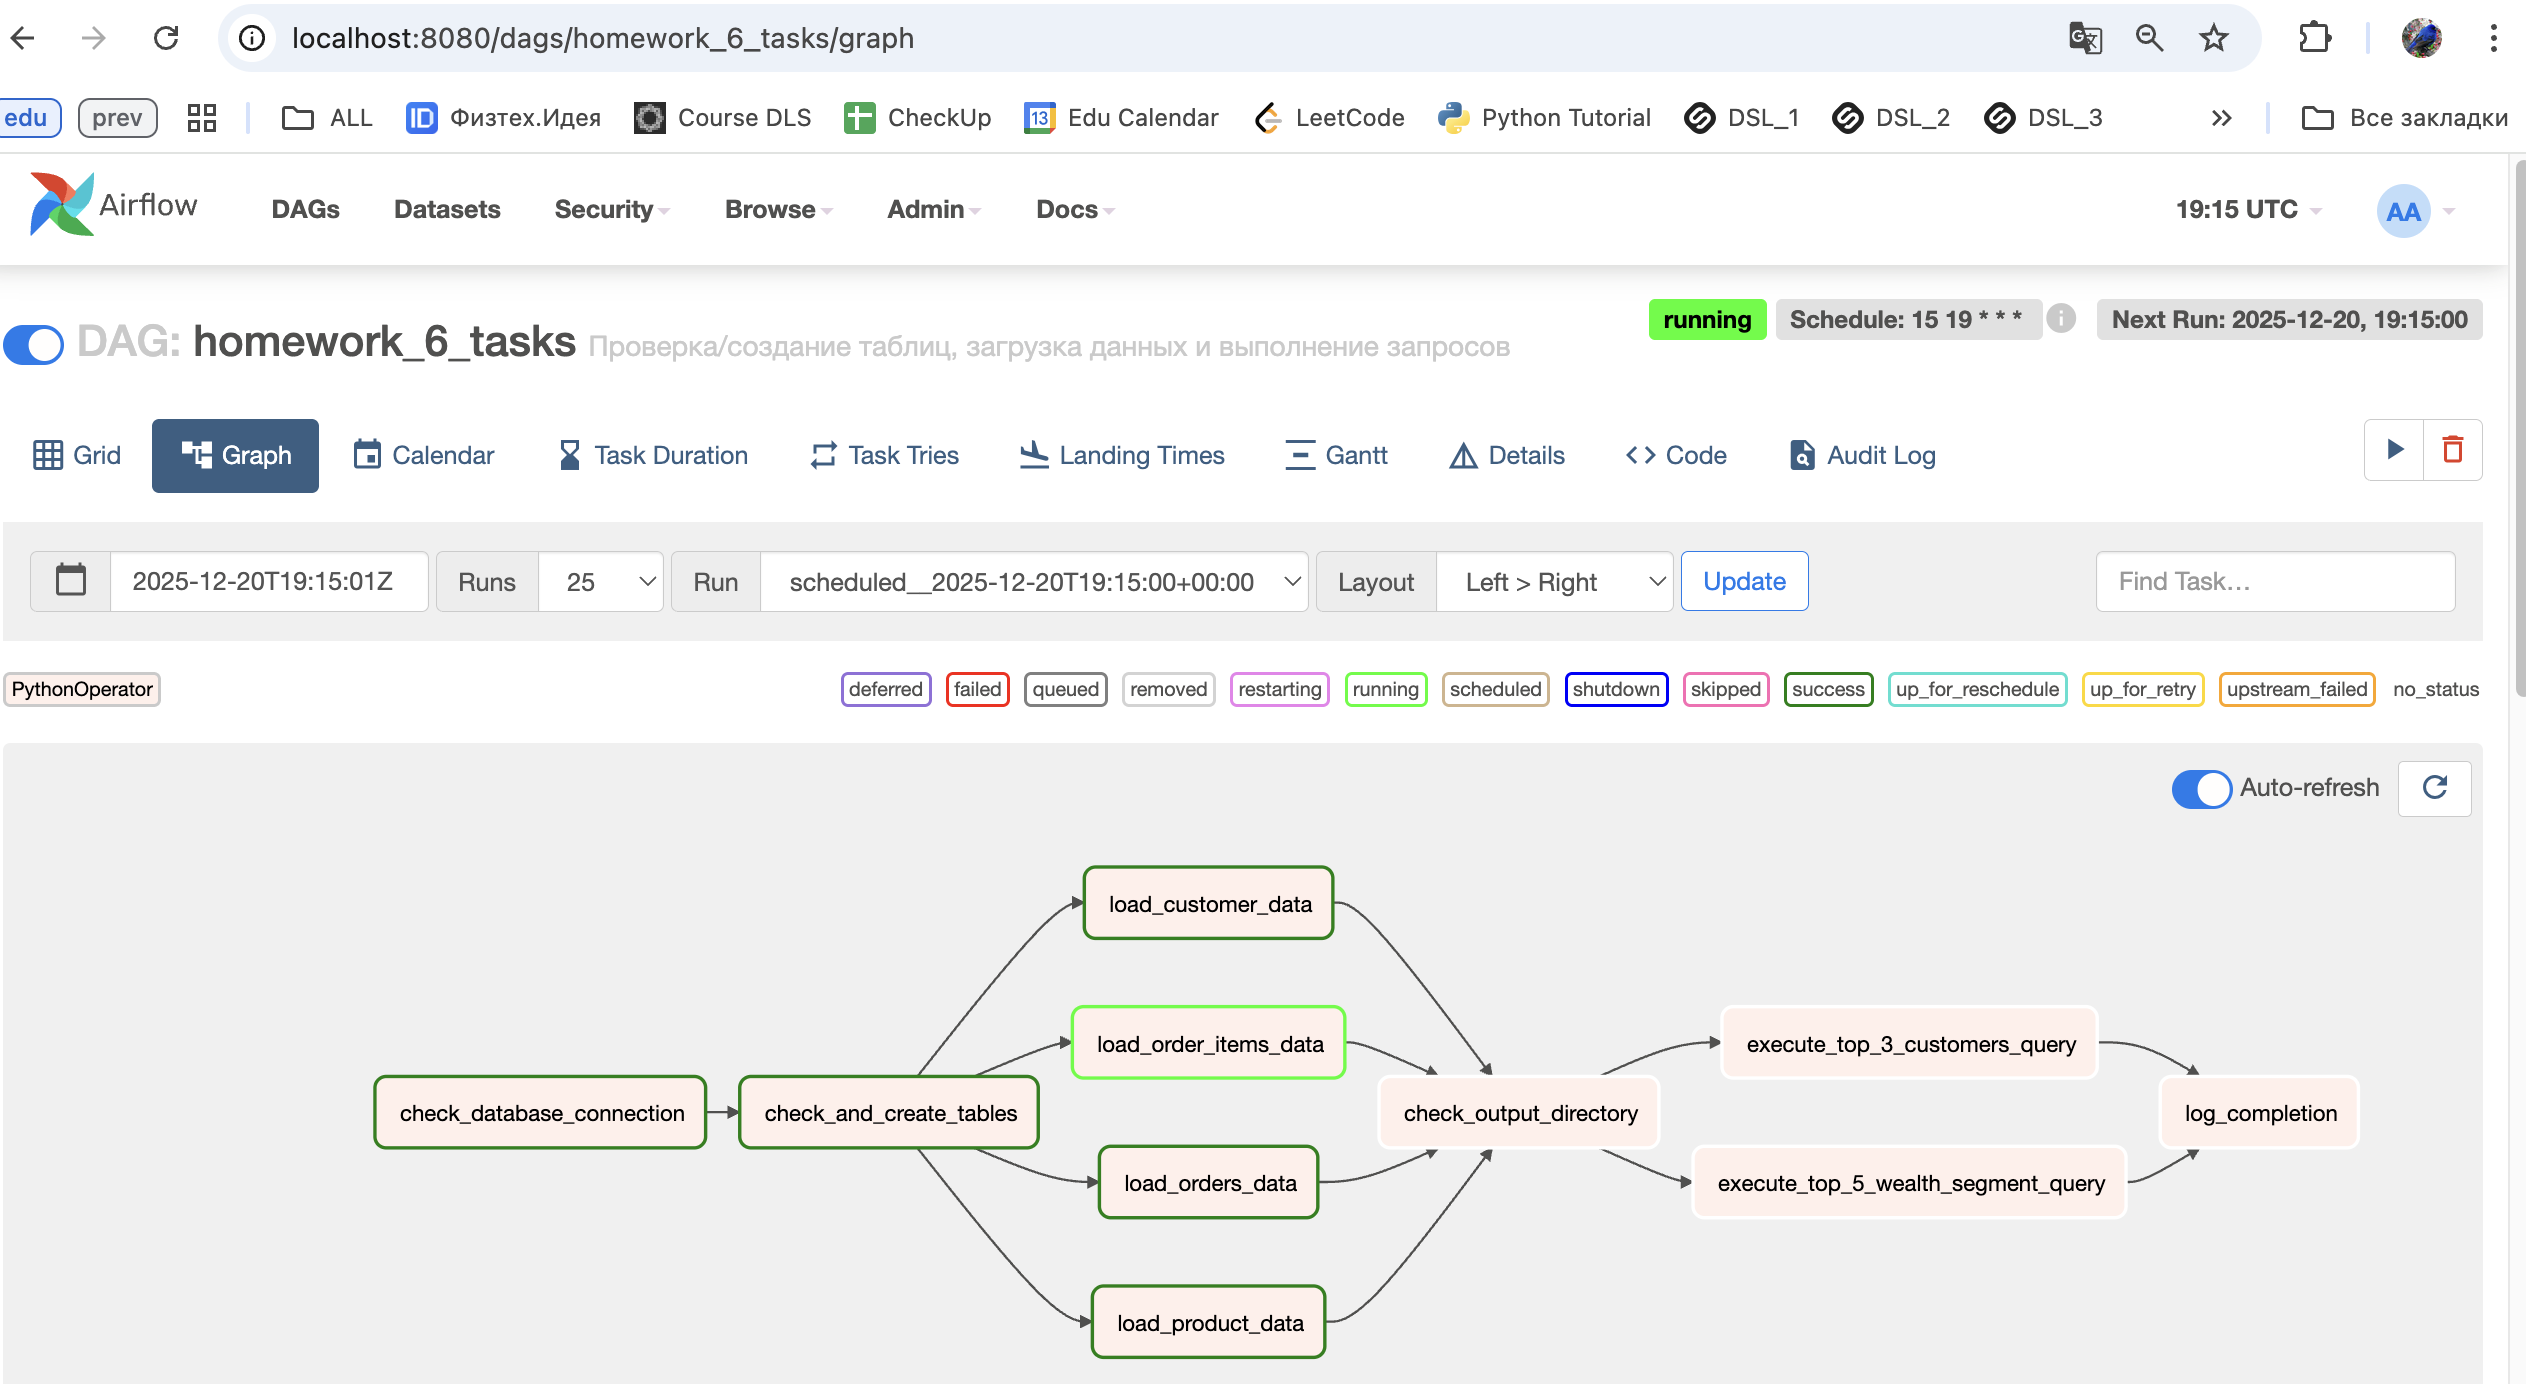

**2. В листе DAGs:**

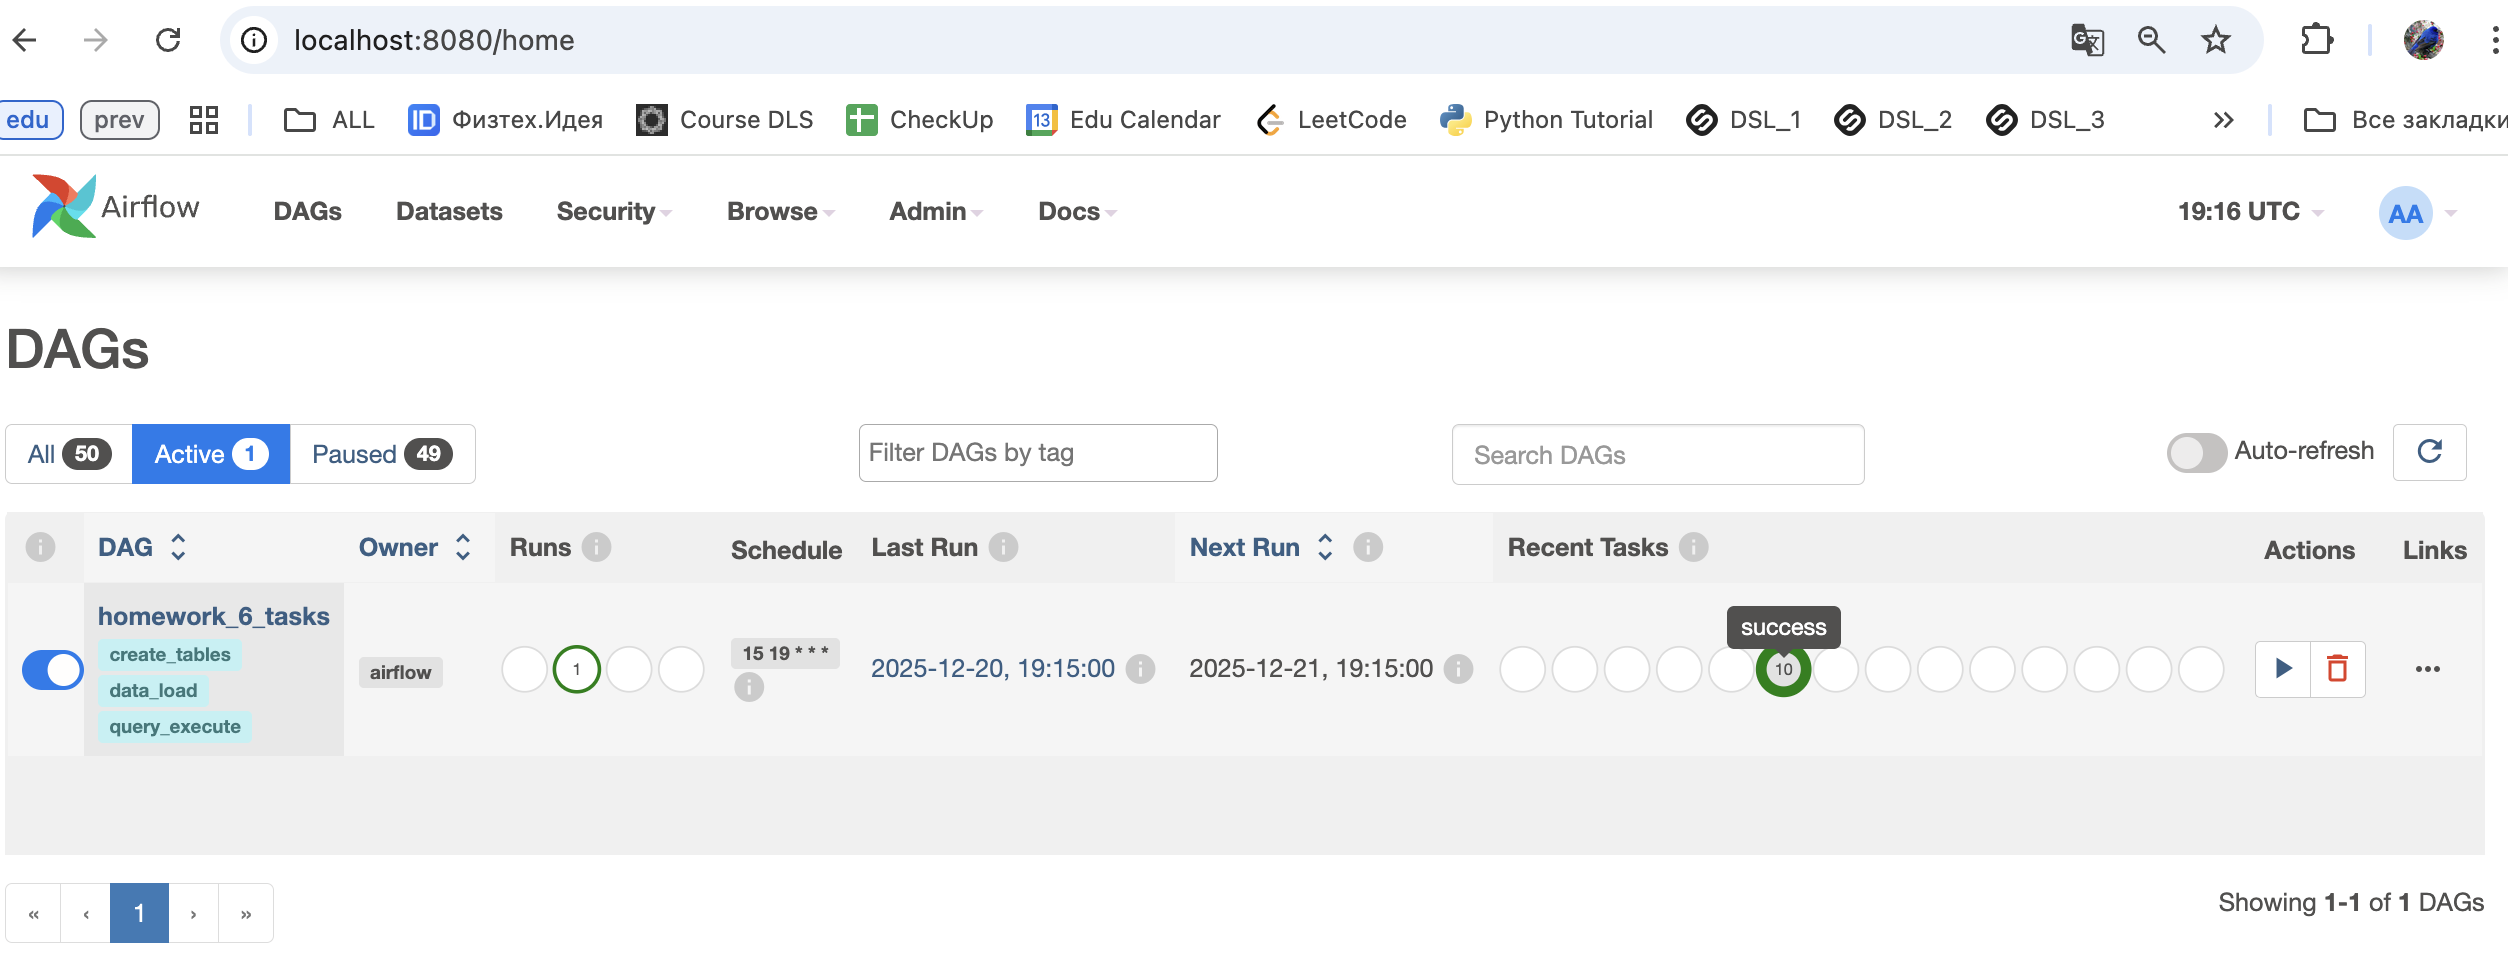

**3. После успешного выполнения всех задач:**

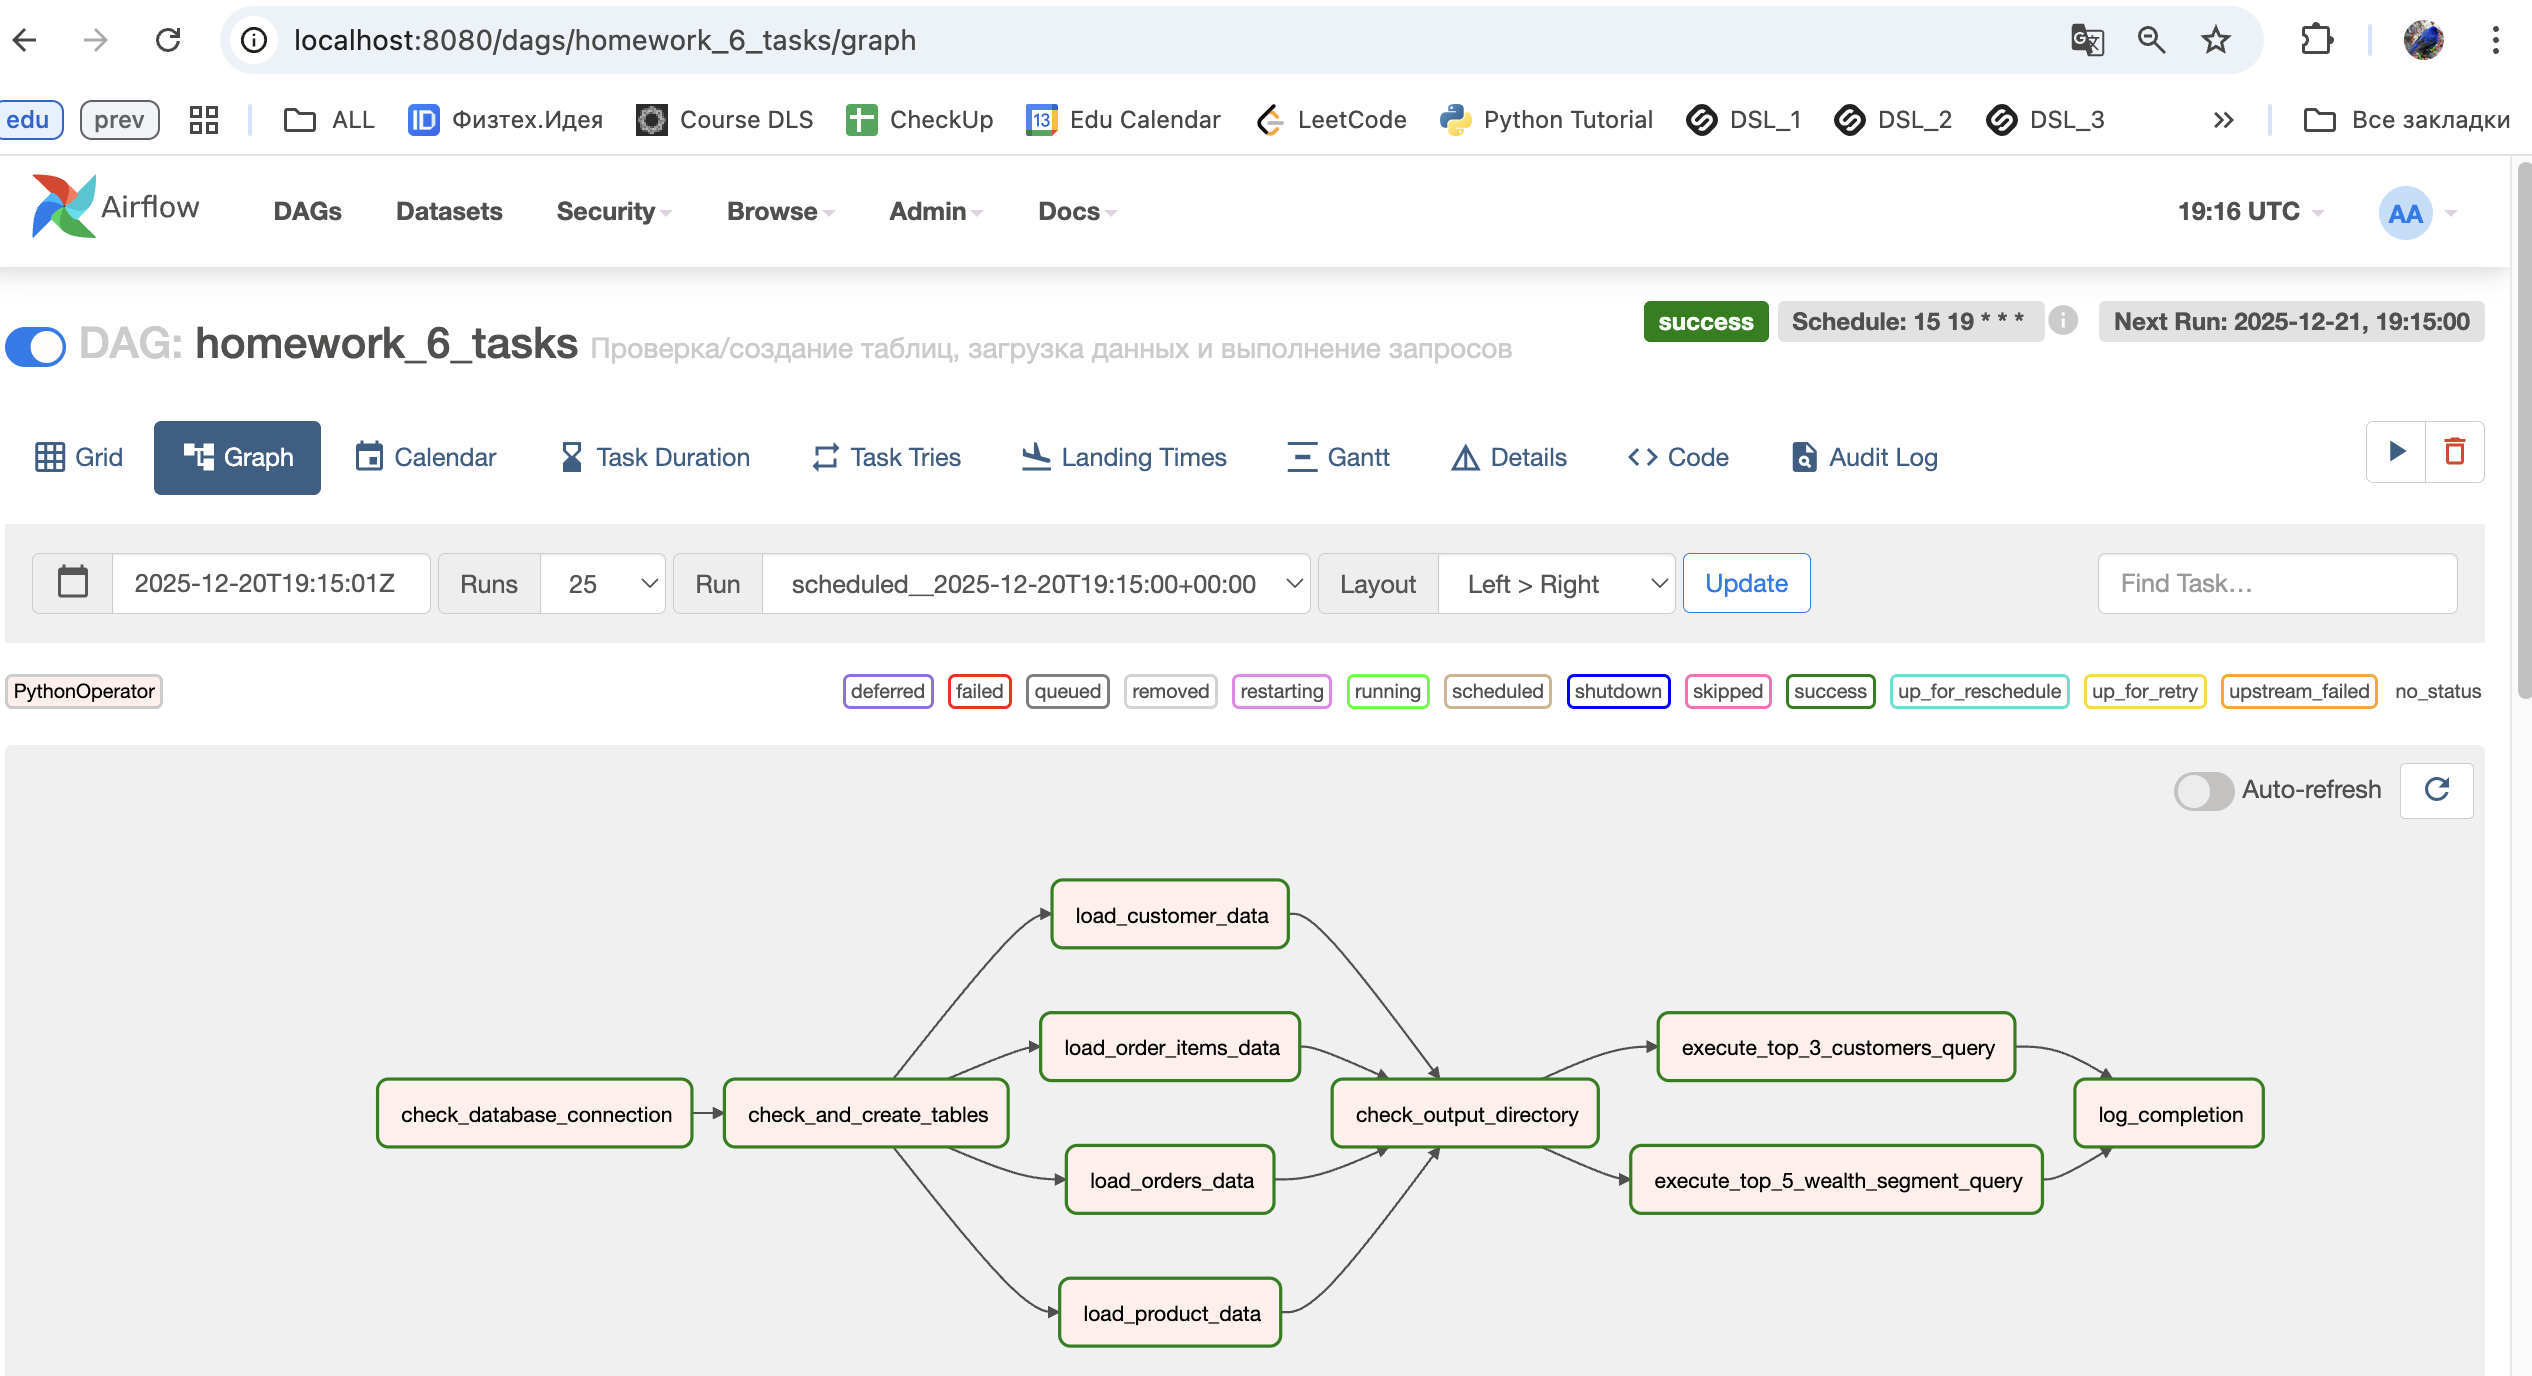

**4. Всплывающее окно после последней успешно завершенной задачи:**

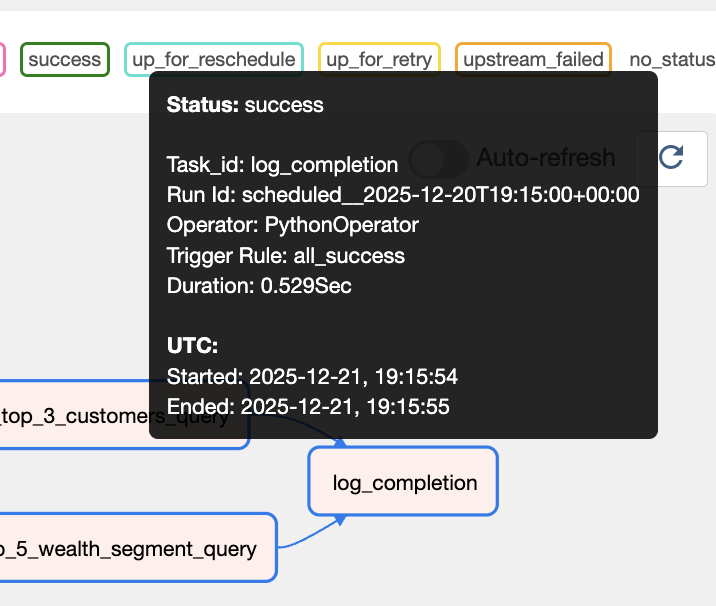

**5. В результате в dag-airflow-worker-1 создается директория /result_files (если еще не была создана), в которую затем сохраняются файлы с результатами:**

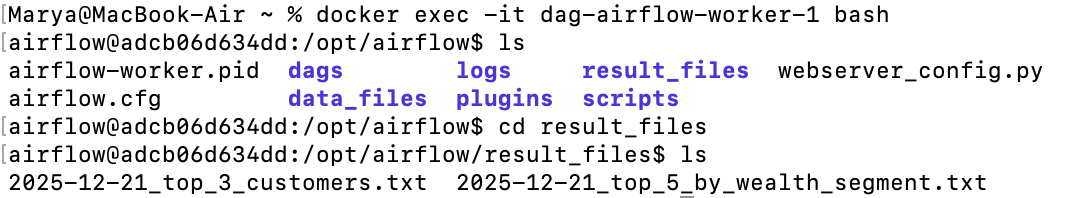

**6. Сохранение топ-3 клиента по максимальной и минимальной сумме заказов в файл yyyy-mm-dd_top_3_customers.txt (yyyy-mm-dd - текущая дата):**

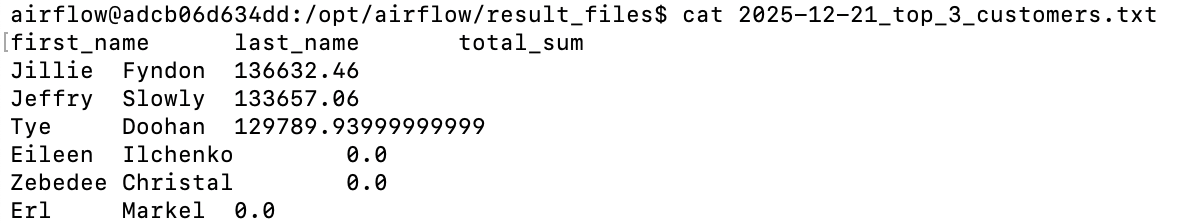

**7. Сохранение топ-5 клиентов по wealth_segment в файл yyyy-mm-dd_top_5_by_wealth_segment.txt:**

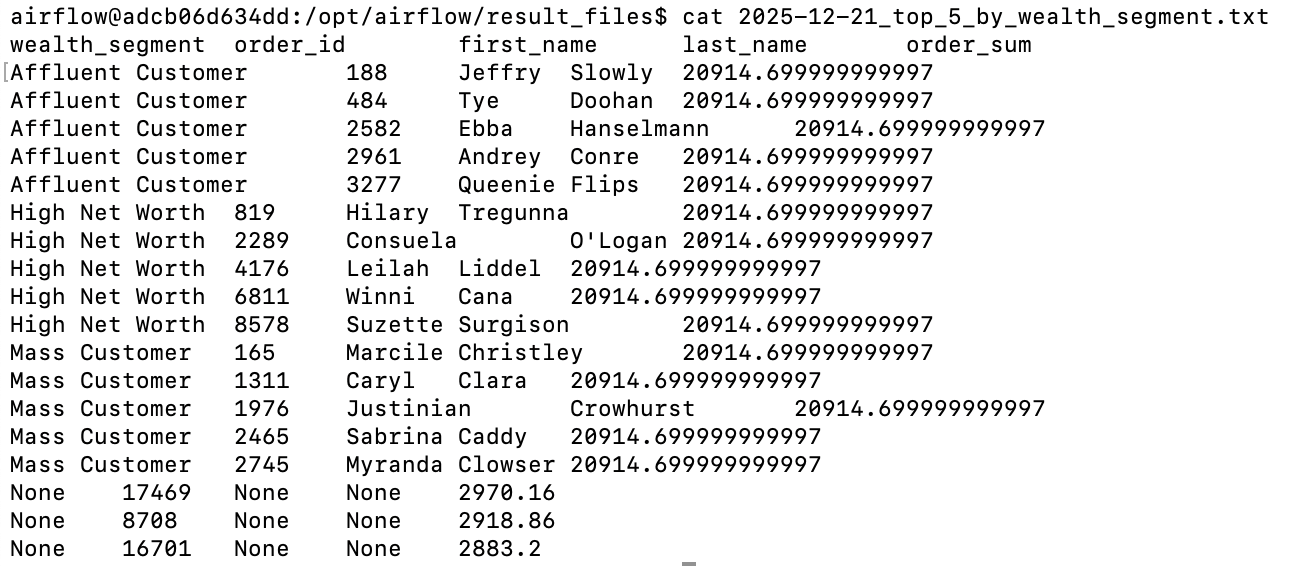